# <div style="text-align: center">**TARDIS - EXPLORATORY DATA ANALYSIS (EDA)**</div>

## Objectif de ce Notebook

Ce notebook EDA effectue le **prétraitement complet des données brutes** pour préparer un dataset nettoyé et exploitable pour l'entraînement du modèle de machine learning. 

Les étapes principales sont :

**Phase de Nettoyage :**
- **Gestion des valeurs manquantes** : Identification et imputation des données incomplètes
- **Gestion des incohérences** : Suppression des doublons, correction des types de données
- **Suppression des colonnes inutiles** : Élimination des commentaires et données non pertinentes

**Phase de Préparation :**
- **Feature Engineering** : Création de nouvelles variables pertinentes pour le modèle
- **Formatage des données** : Conversion des types de données vers des formats exploitables

**Résultat :**
- **Fichier de sortie** : `cleaned_dataset.csv` - Dataset propre, prêt pour l'entraînement du modèle


## Étape 0 : Importation des Modules Nécessaires

Nous importons les librairies essentielles pour le traitement des données :
- **pandas** : Manipulation et analyse des dataframes
- **matplotlib** : Visualisation des données


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Étape 1 : Chargement et Inspection Initiale des Données

Cette première étape permet de **comprendre la structure du dataset brut** :

| Action | Description |
|--------|------------|
| **Shape** | Affiche le nombre de lignes et colonnes du dataset (dimensions) |
| **Info()** | Affiche les types de données de chaque colonne et les valeurs non-nulles |
| **Head()** | Montre les 5 premières lignes pour vérifier le format et le contenu |

**Objectif** : Identifier rapidement les problèmes potentiels avant le nettoyage (types incorrects, valeurs manquantes évidentes, etc.)


In [3]:
df = pd.read_csv("dataset.csv", sep=";")
print(df.shape)
df.info()
df.head()

(12070, 26)
<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains           

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


## Étape 2 : Détection et Suppression des Doublons

**Problème à résoudre** : Les données brutes peuvent contenir des lignes dupliquées (erreurs de collection de données, imports multiples, etc.)

**Actions effectuées** :

1. **Affichage des valeurs manquantes par colonne** (`isnull().sum()`)
   - Permet d'identifier quelles colonnes ont le plus de données manquantes
   - Aide à décider la stratégie de nettoyage pour chaque colonne

2. **Détection des doublons** (`duplicated().sum()`)
   - Compte le nombre exact de lignes dupliquées dans le dataset
   
3. **Suppression des doublons** (`drop_duplicates()`)
   - Élimine les lignes en double pour éviter le biais dans le modèle

4. **Vérification de la nouvelle taille** 
   - Confirme que les doublons ont bien été supprimés
   - Compare avec les dimensions initiales

In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

## Étape 3 : Conversion et Formatage des Types de Données
Les données importées depuis le dataset ont des types incorrects :
- Les dates sont en string (texte) au lieu de datetime
- Les nombres utilisent "," comme séparateur décimal au lieu de "."
- Certaines colonnes numériques sont en string

**Pourquoi ?** : Le modèle de machine learning a besoin de types de données corrects pour faire des calculs numériques et temporels.

**Conversions effectuées** :

| Colonne | Conversion | Raison |
|---------|-----------|--------|
| **Date** | String -> datetime (format: period "M" pour mois) | Permet d'extraire les features temporelles (Year, Month) |
| **Nombres** | Remplacement "," par "." puis conversion en float | Les algorithmes ML ont besoin de nombres en virgule flottante |
| **Colonnes catégoriques** | Service, Stations restent en string | Seront traitées lors du preprocessing final |

**Résultat** : Un dataframe avec les types appropriés, prêt pour les calculs statistiques et le machine learning.


In [5]:
print(df.dtypes)
df["Date"] = pd.to_datetime(df["Date"], format="mixed").dt.to_period("M")

num_cols = df.columns.drop(["Date", "Service", "Departure station", "Arrival station"])
for col in num_cols:
    df[col] = df[col].astype(str).str.replace(",", ".").str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(df.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

## Étape 4 : Imputation des Valeurs Manquantes

Après les conversions de types, certaines valeurs ne peuvent pas être converties (ex: valeurs texte dans une colonne numérique) et deviennent NaN (Not a Number).

**Solution choisie : Imputation par la Médiane**

| Avantage | Description |
|----------|-----------|
| **Robustesse** | La médiane est moins sensible aux valeurs extrêmes que la moyenne |
| **Préservation** | Garde les données dans leur plage naturelle |
| **Simplicité** | Méthode standard et bien adaptée aux données de retards |

**Stratégie** : Pour chaque colonne numérique, remplacer les NaN par la **médiane de la colonne**
- Préserve les caractéristiques statistiques globales
- Évite d'introduire des valeurs extrêmes

**Vérification** : Après imputation, le nombre de valeurs manquantes doit être 0.


In [6]:
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].median())
print(df.isnull().sum())

Date                                                                                59
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                                 0
Number of scheduled trains                                                           0
Number of cancelled trains                                                           0
Cancellation comments                                                            11896
Number of trains delayed at departure                                                0
Average delay of late trains at departure                                            0
Average delay of all trains at departure                                             0
Departure delay comments                   

## Étape 5 : Suppression des Colonnes Inutiles et Nettoyage Final

**Colonnes supprimées** :

| Colonne | Raison de suppression |
|---------|---------------------|
| **Cancellation comments** | Texte descriptif non structuré, impossible à utiliser dans le modèle |
| **Departure delay comments** | Texte descriptif, pas de valeur numérique ou catégorique exploitable |
| **Arrival delay comments** | Texte descriptif, redondant avec les colonnes de retards quantifiées |

**Avantage** : Réduire le bruit dans les données et accélérer le training du modèle.

**Suppression des lignes critiques incomplètes** :

Les colonnes suivantes sont **essentielles pour le modèle** :
- **Date** : Nécessaire pour les features temporelles
- **Service** : Type de service (National/International)
- **Departure station** : Localisation source
- **Arrival station** : Localisation destination

 **Action** : Supprimer toute ligne où l'une de ces colonnes clés est manquante.

**Résultat final** : Un dataset complètement nettoyé, sans valeurs manquantes critiques, prêt pour l'analyse et le feature engineering.


In [7]:
df = df.drop(
    columns=[
        "Cancellation comments",
        "Departure delay comments",
        "Arrival delay comments",
    ],
    errors="ignore",
)
print(df.isnull().sum())
df = df.dropna(subset=["Date", "Service", "Departure station", "Arrival station"])
print(df.isnull().sum())

Date                                                                              59
Service                                                                          240
Departure station                                                                 59
Arrival station                                                                   59
Average journey time                                                               0
Number of scheduled trains                                                         0
Number of cancelled trains                                                         0
Number of trains delayed at departure                                              0
Average delay of late trains at departure                                          0
Average delay of all trains at departure                                           0
Number of trains delayed at arrival                                                0
Average delay of late trains at arrival                          

## Étape 6 : Feature Engineering - Création de Nouvelles Variables

**Objectif** : Créer des variables pertinentes qui amélioreront la capacité prédictive du modèle.

**Nouvelles Features créées** :

### 1. **Year** - Année d'observation
- **Source** : Extraction de la colonne Date
- **Type** : Numérique (2018, 2019, etc.)

### 2. **Month** - Mois d'observation
- **Source** : Extraction de la colonne Date
- **Type** : Numérique (1-12)

### 3. **Delay categories** - Catégorisation des retards
- **Logique de classification** :
  - **"delay null"** : Retard ≤ 0 min (trains en avance)
  - **"minor delay"** : 0 < Retard < 5 min
  - **"average delay"** : 5 ≤ Retard < 15 min
  - **"major delay"** : 15 ≤ Retard < 30 min
  - **"severe delay"** : Retard ≥ 30 min

### 4. **is_delayed** - Indicateur binaire de retard
- **Définition** : Retard > 5 minutes = 1, sinon = 0
- **Utilité** : Variable cible alternative pour une classification binaire
- **Type** : Binaire (0 ou 1)

### 5. **Cancellation_rate** - Taux d'annulation
- **Formule** : Nombre de trains annulés / Nombre de trains programmés
- **Valeur** : Entre 0 et 1
- **Type** : Numérique

**Impact sur le modèle** : Ces features capturent différentes dimensions des retards (temporelles, catégoriques, opérationnelles) permettant au modèle d'apprendre des patterns plus complexes et nuancés.


In [8]:
# Ajout d'une nouvelle colonne pour les années
df["Year"] = df["Date"].dt.year

# Ajout d'une nouvelle colonne pour les mois
df["Month"] = df["Date"].dt.month


# Catégorisation du type de retard de chaque type de train
def categorize_delay(delay):
    if delay <= 0:
        return "delay null"
    if delay < 5:
        return "minor delay"
    if delay < 15:
        return "average delay"
    if delay < 30:
        return "major delay"
    return "severe delay"


# Ajout d'une nouvelle colonne pour catégoriser les types de retard
df["Delay categories"] = df["Average delay of all trains at arrival"].apply(
    categorize_delay
)

# Création d'un tableau de booléen pour les retards (0 lorsque c'est inférieur à 5 min et 1 dans le cas contraire)
df["is_delayed"] = (df["Average delay of all trains at arrival"] > 5).astype(int)

# Ajout d'une colonne pour le taux d'annulation des trains.
df["Cancellation_rate"] = (
    df["Number of cancelled trains"] / df["Number of scheduled trains"]
)

# Affichage des infos et des 5 premières lignes pour vérifier les nouvelles colonnes
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 11487 entries, 0 to 12060
Data columns (total 28 columns):
 #   Column                                                                         Non-Null Count  Dtype    
---  ------                                                                         --------------  -----    
 0   Date                                                                           11487 non-null  period[M]
 1   Service                                                                        11487 non-null  str      
 2   Departure station                                                              11487 non-null  str      
 3   Arrival station                                                                11487 non-null  str      
 4   Average journey time                                                           11487 non-null  float64  
 5   Number of scheduled trains                                                     11487 non-null  float64  
 6   Number of cancelled tr

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,Delay categories,is_delayed,Cancellation_rate
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,2018,1,average delay,1,0.005747
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,average delay,1,0.002463
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,minor delay,0,0.000000
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,average delay,1,0.005906
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,45.614035,18.750000,15.789474,1.754386,1.754386,2018,1,minor delay,0,0.008475


## Étape 7 : Création du Dataset Nettoyé

**Processus de sauvegarde** :

| Paramètre | Valeur | Raison |
|-----------|--------|--------|
| **Copie du dataframe** | `df.copy()` | Préserver le dataframe original en mémoire |
| **Conversion de Date** | `astype(str)` | Convertir le format period en string pour le CSV |
| **Fichier de sortie** | `cleaned_dataset.csv` | Format standard, compatible avec pandas/sklearn |
| **index=False** | Désactifé | Éviter de créer une colonne d'index superflu (0, 1, 2, ...) |
| **sep=";"** | Point-virgule | Séparateur identique au fichier source pour cohérence |

**Résultat** :
- Dataset complètement nettoyé et prétraité
- Valeurs manquantes imputées
- Types de données corrects
- Nouvelles features engineering
- Prêt pour le modèle de machine learning

**Prochaine étape** : Charger ce fichier nettoyé dans `tardis_model.ipynb` pour l'entraînement.


In [9]:
df_save = df.copy()
df_save["Date"] = df_save["Date"].astype(str)
df_save.to_csv("cleaned_dataset.csv", index=False, sep=";")

## Étape 8 : Analyse Statistique et Visualisation des Données

**Objectif** : Comprendre les distributions et les caractéristiques du dataset nettoyé pour :
- Identifier les anomalies résiduelles
- Comprendre les patterns des retards

**Statistiques descriptives** (`describe()`) :

Génère un résumé pour chaque colonne numérique :
- **count** : Nombre de valeurs (doit être identique pour toutes)
- **mean** : Moyenne (tendance centrale)
- **std** : Écart-type (variabilité)
- **min/max** : Valeurs extrêmes
- **25%, 50%, 75%** : Quartiles (permet d'identifier la distribution)

In [10]:
df.describe()

/home/g4n0/tardis-sncf/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,...,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,is_delayed,Cancellation_rate
count,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,...,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,11487.000000,1.147700e+04
mean,170.717606,269.847393,8.522155,86.131018,12.280867,3.114113,37.231218,35.165504,6.032187,26.721947,...,21.519693,21.833450,20.340711,18.823239,7.328028,7.524158,2021.477148,6.508749,0.554627,inf
std,87.158480,181.148665,22.485107,89.889151,11.797584,5.150872,30.982813,15.603547,7.043240,22.433254,...,15.809881,14.743469,14.517051,13.351277,7.933677,9.362719,2.313941,3.450590,0.497029,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-472.638889,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.000000,1.000000,0.000000,0.000000e+00
25%,101.000000,152.000000,0.000000,22.000000,6.278403,1.224653,15.000000,25.946538,3.432344,11.000000,...,10.714286,12.162162,10.526316,10.186787,0.000000,0.000000,2019.000000,4.000000,0.000000,0.000000e+00
50%,164.000000,229.000000,2.000000,52.000000,10.380278,2.330422,29.000000,33.465686,5.346720,21.000000,...,19.047619,20.000000,18.750000,17.105263,5.882353,5.000000,2021.000000,7.000000,1.000000,7.142857e-03
75%,222.000000,351.000000,7.000000,125.000000,15.569530,3.890184,50.000000,42.254547,8.000769,36.000000,...,29.411765,29.411765,28.179058,25.000000,10.869565,11.111111,2024.000000,9.000000,1.000000,3.105590e-02
max,786.000000,1100.000000,297.000000,1066.000000,316.188000,115.047390,376.000000,299.600000,92.000000,312.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2025.000000,12.000000,1.000000,inf


### **<div style="text-align: center">I- Distribution des données</div>**
 
En analyse de données, une distribution décrit la manière dont les valeurs d'une variable sont réparties. Elle indique quelles valeurs sont fréquentes, rares ou extrêmes, permettant de comprendre la forme et le comportement global des données.

#### **<div style="text-align: center">Histogramme du retard à l'arrivée</div>**

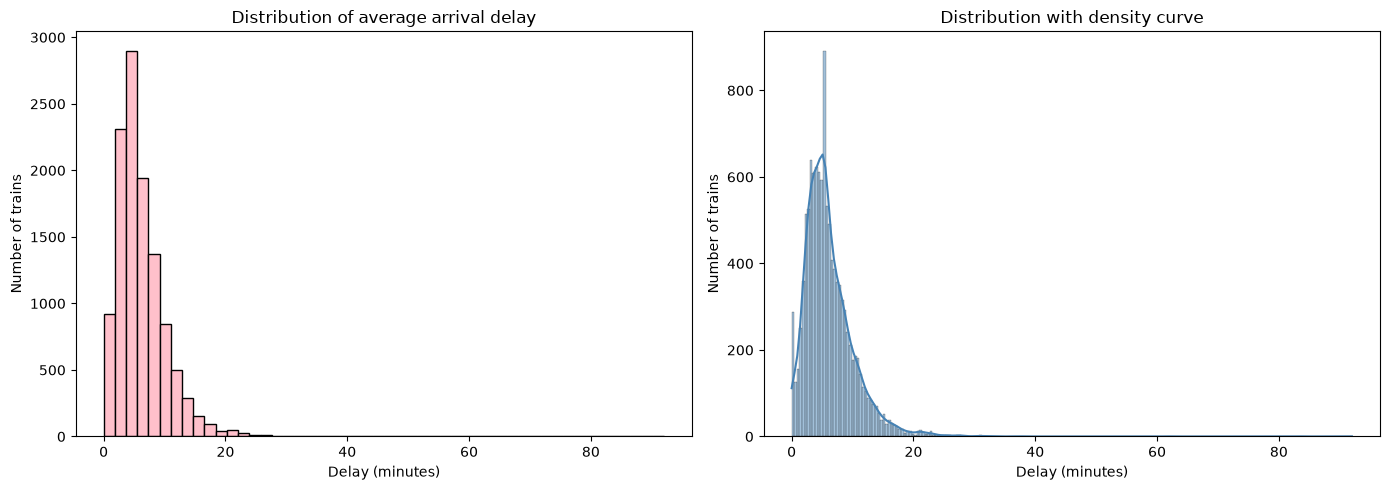

In [11]:
df.loc[
    df["Average delay of all trains at arrival"] < 0,
    "Average delay of all trains at arrival",
] = 0
df.loc[
    df["Average delay of all trains at departure"] < 0,
    "Average delay of all trains at departure",
] = 0


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogramme du retard moyen des trains à l'arrivée

axes[0].hist(
    df["Average delay of all trains at arrival"],
    bins=50,
    color="pink",
    edgecolor="black",
)
axes[0].set_title("Distribution of average arrival delay")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Number of trains")

# Courbe de densité du retard moyen des trains à l'arrivée

sns.histplot(
    df["Average delay of all trains at arrival"],
    kde=True,
    ax=axes[1],
    color="steelblue",
)
axes[1].set_title("Distribution with density curve")
axes[1].set_xlabel("Delay (minutes)")
axes[1].set_ylabel("Number of trains")

plt.tight_layout()
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
[6:15 PM] Maryline frieda bignon Chatigre
De l'analyse du graphe, la distribution est fortement asymétrique à droite.
La majorité des retards se concentrent entre 0 et 15 minutes, avec un pic
autour de 4-6 minutes. La courbe de densité confirme cette forme : une montée
rapide puis une descente progressive avec une longue queue vers la droite.
 
De plus, les retards supérieurs à 40 minutes sont rares mais existent, représentant
des perturbations exceptionnelles. Cette asymétrie suggère qu'une transformation
logarithmique de la target pourrait améliorer les performances du modèle,
car la régression linéaire suppose une distribution plus symétrique.

#### **<div style="text-align: center">Diagramme en boîte du retard à l'arrivée</div>**

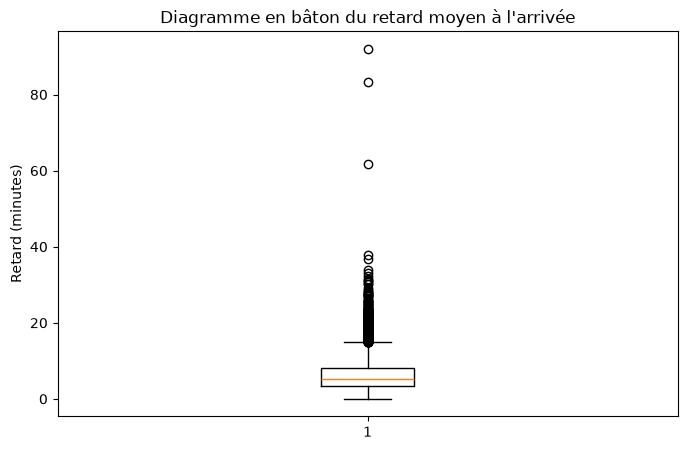

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Average delay of all trains at arrival"])
plt.title("Diagramme en bâton du retard moyen à l'arrivée")
plt.ylabel("Retard (minutes)")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
**1. Le minimum**
La minimum descend jusqu'à 0 minute.
C'est la valeur la plus basse encore considérée comme normale.
 
**2. Le premier quartile - Q1**
Q1 se situe autour de 1-2 minutes.
Cela signifie que 25% des lignes du dataset ont un retard
inférieur à cette valeur.
 
**3. La médiane — Q2 (ligne orange)**
La médiane est autour de 5-6 minutes.
C'est la valeur centrale : 50% des retards sont en dessous et 50% au-dessus.
Elle est plus représentative que la moyenne car elle n'est pas influencée par les outliers extrêmes.
 
**4. Le troisième quartile — Q3 (haut de la boîte)**
Q3 se situe autour de 8-9 minutes.
75% des lignes ont un retard inférieur à cette valeur.
La boîte (Q1 à Q3) représente donc l'intervalle interquartile qui contient 50% des données, ici très resserrée, ce qui confirme que la majorité des retards sont faibles et homogènes.
 
**5. Le maximum (moustache haute)**
La moustache supérieure s'étend jusqu'à environ 15-16 minutes.
Tout ce qui dépasse est considéré comme un outlier.
 
**Les outliers (cercles)**
On observe de nombreux outliers entre 20 et 40 minutes, et trois cas extrêmes à 62, 83 et 91 minutes.
Ces valeurs correspondent probablement à des perturbations exceptionnelles (grèves, accidents, conditions météorologiques sévères).

#### **<div style="text-align: center">Distribution du retard au départ vs à l'arrivée</div>**

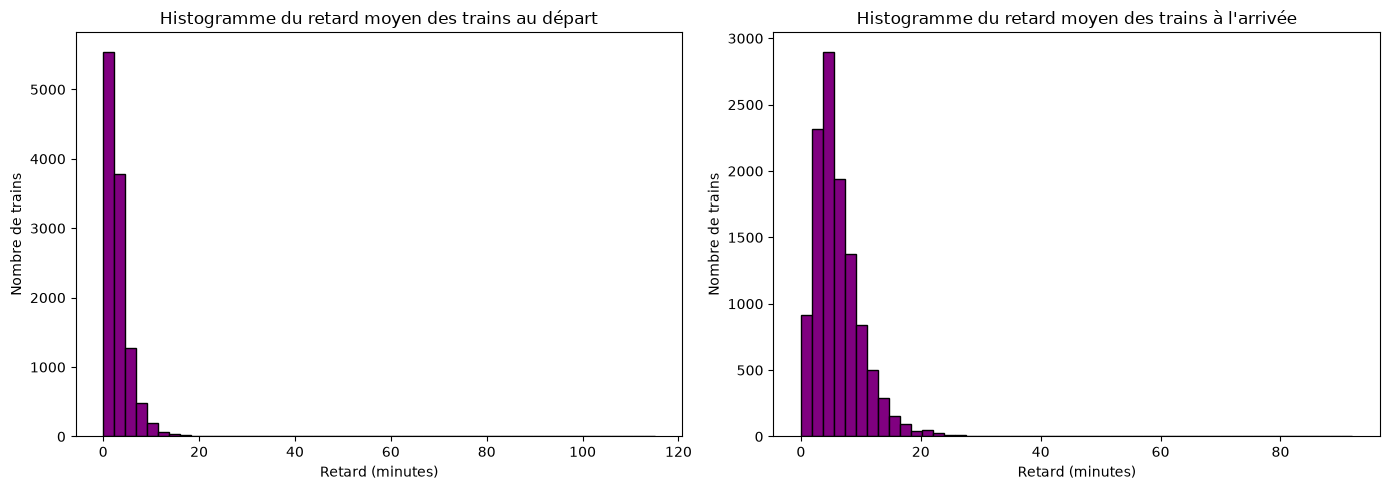

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["Average delay of all trains at departure"],
    bins=50,
    color="purple",
    edgecolor="black",
)
axes[0].set_title("Histogramme du retard moyen des trains au départ")
axes[0].set_xlabel("Retard (minutes)")
axes[0].set_ylabel("Nombre de trains")

axes[1].hist(
    df["Average delay of all trains at arrival"],
    bins=50,
    color="purple",
    edgecolor="black",
)
axes[1].set_title("Histogramme du retard moyen des trains à l'arrivée")
axes[1].set_xlabel("Retard (minutes)")
axes[1].set_ylabel("Nombre de trains")

plt.tight_layout()
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Les deux distributions sont asymétriques à droite, confirmant que les petits retards sont largement majoritaires.
 
Cependant, une différence notable apparaît :
- Le retard au **départ** est encore plus concentré autour de 0-2 minutes,
  avec un pic très marqué à près de 5500 enregistrements.
- Le retard à l'**arrivée** est plus étalé, avec un pic autour de 4-6 minutes.
 
Cela suggère que les trains accumulent du retard en cours de route :
ils partent avec peu ou pas de retard mais arrivent avec plus.

#### **<div style="text-align: center">Distribution du retard en fonction des causes</div>**

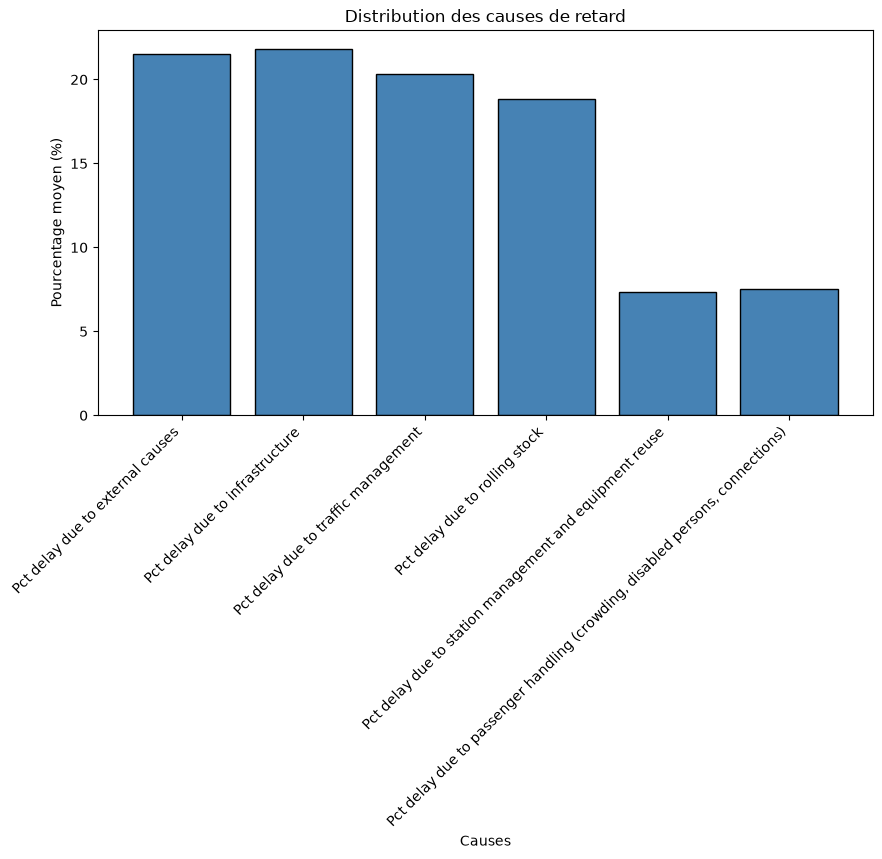

In [14]:
causes = [
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
]

means = df[causes].mean()
plt.figure(figsize=(10, 5))
plt.bar(causes, means.values, color="steelblue", edgecolor="black")
plt.title("Distribution des causes de retard")
plt.xlabel("Causes")
plt.ylabel("Pourcentage moyen (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
 
Les quatre principales causes de retard sont relativement équilibrées :
- **Infrastructure** : ~22% - la cause dominante, liée aux pannes
  de signalisation, aiguillages et caténaires.
- **Causes externes** : ~21.5% - météo, personnes sur les voies, colis suspects.
- **Gestion du trafic** : ~20.5% - saturation du réseau, conflits d'horaires.
- **Matériel roulant** : ~19% — pannes de locomotives ou wagons.
 
Les deux causes mineures sont :
- **Gestion en gare** : ~7.5%
- **Gestion des voyageurs** : ~7.5%

### **<div style="text-align: center">II- Comparaison des données</div>**
 
En analyse de données, la comparaison consiste à confronter deux ou plusieurs ensembles de données, variables ou scénarios pour identifier leurs similitudes, leurs différences, leurs forces et leurs faiblesses. Elle permet de contextualiser l'information, de détecter des anomalies et de prendre des décisions éclairées.

#### **<div style="text-align: center">Comparaison mensuel</div>**

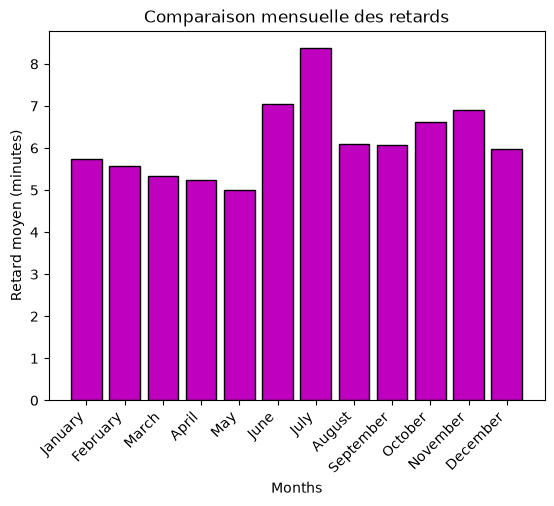

In [15]:
grouped_by_month = df.groupby("Month")["Average delay of all trains at arrival"].mean()

months = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
plt.bar(months, grouped_by_month.values, color="m", edgecolor="black")
plt.title("Comparaison mensuelle des retards")
plt.xlabel("Months")
plt.ylabel("Retard moyen (minutes)")
plt.xticks(rotation=45, ha="right")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Le retard moyen varie entre 5 et 8.3 minutes selon le mois.
 
Les mois d'**été (juin-juillet)** affichent les retards les plus élevés, avec un pic en juillet à 8.3 minutes. Cela s'explique par l'augmentation du trafic voyageurs durant les vacances, qui génère une saturation du réseau.
 
Les mois de **printemps (avril-mai)** présentent les retards les plus faibles,
autour de 5 minutes.
 
Cette saisonnalité confirme que les mois d'été sont systématiquement plus problématiques que les autres périodes de l'année.

#### **<div style="text-align: center">Comparaison des retards par année</div>**

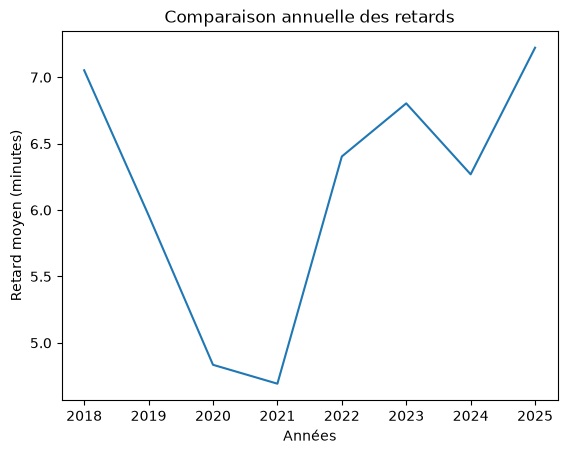

In [16]:
grouped_by_year = df.groupby("Year")["Average delay of all trains at arrival"].mean()

plt.plot(grouped_by_year.index, grouped_by_year.values)
plt.title("Comparaison annuelle des retards")
plt.xlabel("Années")
plt.ylabel("Retard moyen (minutes)")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Le retard moyen a fortement diminué entre 2018 (7 minutes) et 2021 (4.7 minutes), période qui correspond au Covid-19: moins de trains en circulation signifie moins de congestion et donc moins de retards.
 
Depuis 2021, les retards repartent à la hausse pour atteindre 7.2 minutes en 2025, dépassant même le niveau de 2018.
Cette tendance ascendante post-Covid suggère que le réseau est sous pression croissante.

#### **<div style="text-align: center">Comparaison des retards par services</div>**

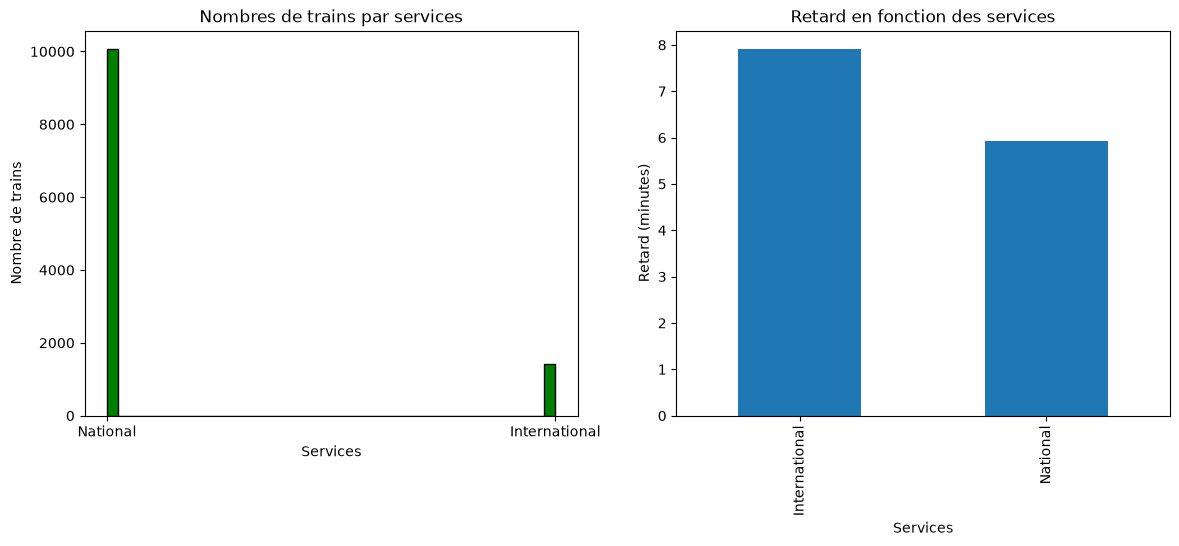

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_by_service = df.groupby("Service")["Average delay of all trains at arrival"].mean()
avg_by_service.plot(kind="bar")

axes[0].hist(df["Service"], bins=40, color="green", edgecolor="black")
axes[0].set_title("Nombres de trains par services")
axes[0].set_xlabel("Services")
axes[0].set_ylabel("Nombre de trains")

axes[1].set_title("Retard en fonction des services")
axes[1].set_xlabel("Services")
axes[1].set_ylabel("Retard (minutes)")

plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Après analyse du graphe, on remarque que:
 
- le dataset est très déséquilibré :
les trains nationaux représentent environ 87% des données tandis que les internationaux seulement 13%.
 
- Le secteur international affiche les retards les plus élevés avec un pic jusqu'à près de minutes.

#### **<div style="text-align: center">Comparaison des retards entre stations</div>**

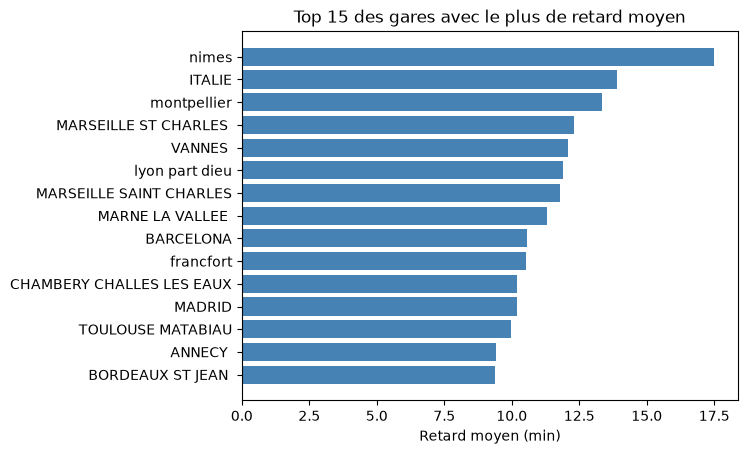

In [18]:
station_delays = (
    df.groupby("Departure station")["Average delay of all trains at arrival"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.barh(station_delays.index, station_delays.values, color="steelblue")
plt.title("Top 15 des gares avec le plus de retard moyen")
plt.xlabel("Retard moyen (min)")
plt.gca().invert_yaxis()
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
De l'analyse du graphe, on note que **la majorité des retards provient de la gare nimes**.
Cela peut s'expliquer son trafic élevé, sa localisation
ou des problèmes d'infrastructure spécifiques.

### **<div style="text-align: center">III- Corrélation des données</div>**
En analyse de données, la corrélation est une mesure statistique qui évalue la relation entre deux ou plusieurs variables. Elle indique si—et dans quelle mesure—les variations de la valeur d'une variable sont associées aux variations d'une autre, permettant ainsi d'identifier des tendances et des modèles

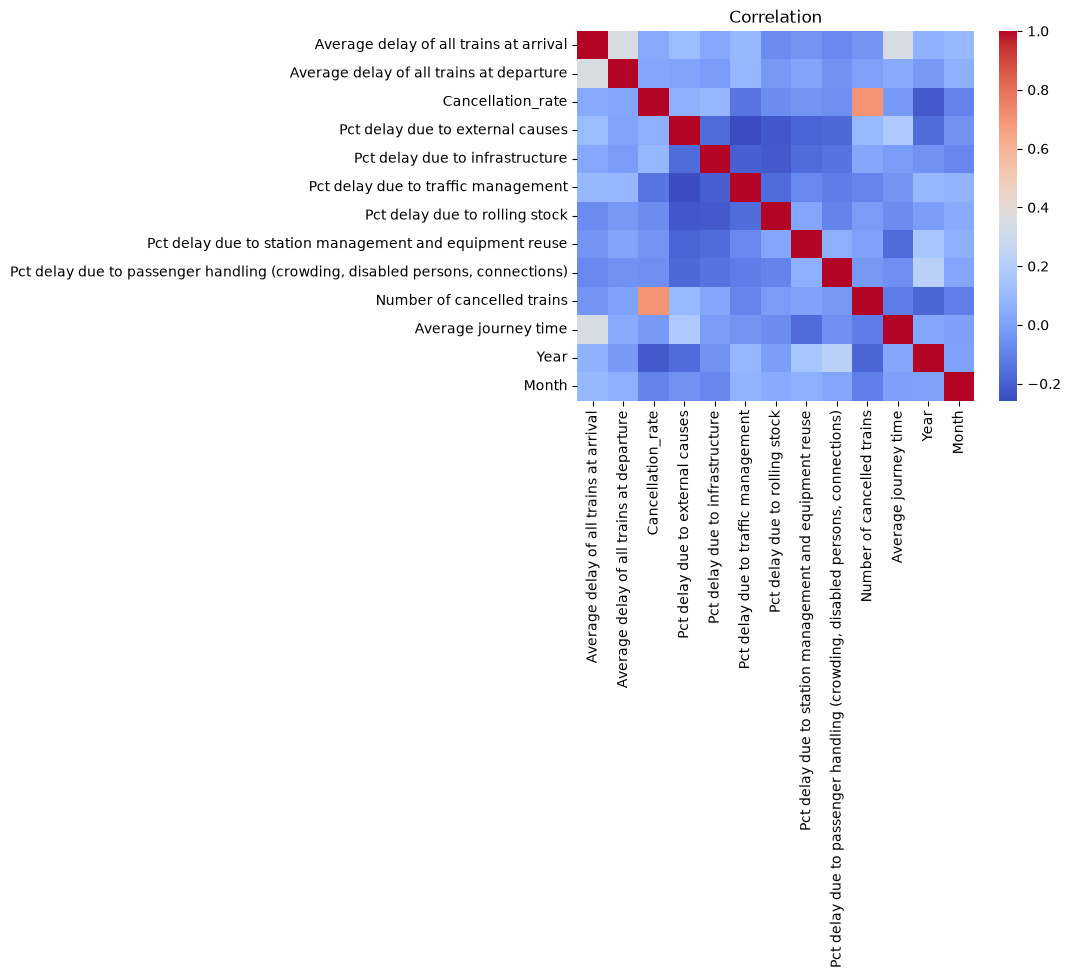

In [19]:
cols_corr = [
    "Average delay of all trains at arrival",
    "Average delay of all trains at departure",
    "Cancellation_rate",
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
    "Number of cancelled trains",
    "Average journey time",
    "Year",
    "Month",
]
plt.title("Correlation")
sns.heatmap(df[cols_corr].corr(), annot=False, cmap="coolwarm")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
La heatmap révèle plusieurs informations importantes pour le modèle.
 
**Corrélations avec la target (Average delay of all trains at arrival) :**
- `Average delay of all trains at departure` est modéremment corrélé à la target: un train en retard au départ arrive très souvent en retard.
- `Average journey time` montre également une corrélation modérée positive.
- `Year`, `Month` et `Cancellation_rate` montrent des corrélations très faibles avec la target, ce qui suggère qu'ils apporteront peu d'information au modèle seuls.
 
**Corrélations entre features (multicolinéarité) :**
- Les colonnes de causes de retard (infrastructure, external, rolling stock...) sont négativement corrélées entre elles (bleu foncé). C'est logique car elles sont des pourcentages qui doivent sommer à 100% — si l'une monte, les autres baissent mécaniquement.
- Cette multicolinéarité entre causes peut poser problème pour la régression
  linéaire.
 
Les features les plus pertinentes à retenir sont `Average delay at departure` et `Average journey time`.

#### **<div style="text-align: center">Diagramme de dispersion du retard au départ et à l'arrivée des trains</div>**

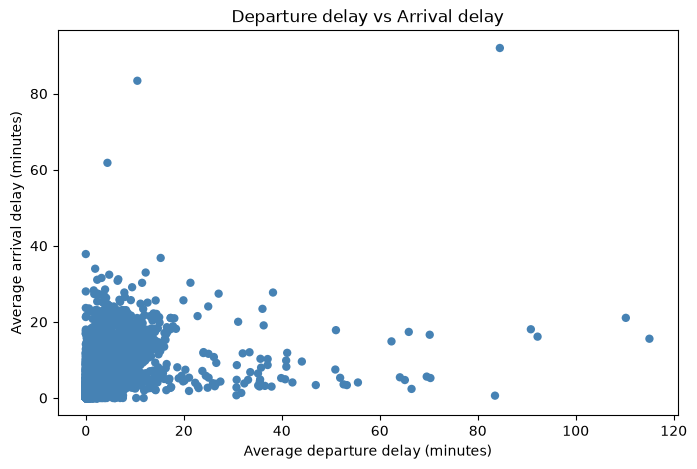

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Average delay of all trains at departure"],
    df["Average delay of all trains at arrival"],
    color="steelblue",
    edgecolor="none",
)
plt.title("Departure delay vs Arrival delay")
plt.xlabel("Average departure delay (minutes)")
plt.ylabel("Average arrival delay (minutes)")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Le nuage de points montre une concentration très dense dans le coin inférieur gauche (0-20 minutes pour les deux axes),
confirmant que la majorité des trains ont de faibles retards au départ comme à l'arrivée.
 
On observe une tendance positive générale : plus le retard au départ est élevé, plus le retard à l'arrivée tend à l'être aussi.
Cependant, la relation n'est pas parfaitement linéaire.Certains trains avec un fort retard au départ arrivent avec peu de retard, et inversement.
 
Les quelques outliers isolés (retard arrivée > 60 minutes avec un faible retard départ) correspondent probablement à des incidents survenus en cours de trajet.

#### **<div style="text-align: center">Diagramme de distribution du temps de voyage et du retard d'arrivée des trains</div>**

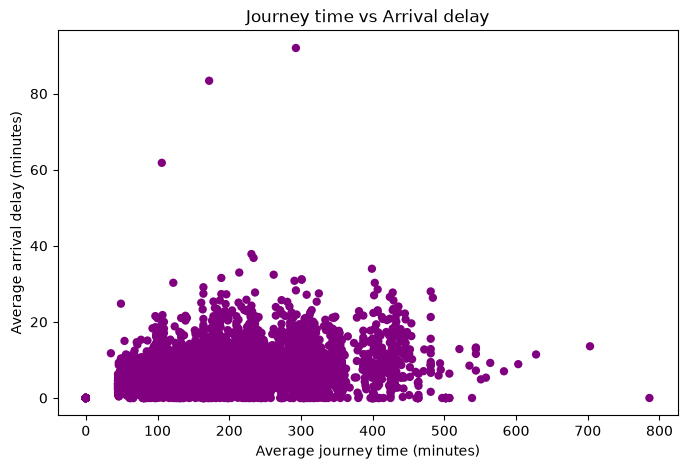

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Average journey time"],
    df["Average delay of all trains at arrival"],
    color="purple",
    edgecolor="none",
)
plt.title("Journey time vs Arrival delay")
plt.xlabel("Average journey time (minutes)")
plt.ylabel("Average arrival delay (minutes)")
plt.show()

#### **<div style="text-align: center">Analyse:</div>**
 
Le nuage de points ne montre pas de relation linéaire claire entre la durée du trajet et le retard à l'arrivée.
 
Les retards les plus élevés (20-90 minutes) apparaissent principalement sur des trajets de 100 à 400 minutes.
Les trajets très courts (<100 minutes) et très longs (>500 minutes) semblent moins affectés par les grands retards.
 
La dispersion importante du nuage indique que la durée du trajet seule n'est pas un bon prédicteur du retard. Elle apporte néanmoins une information contextuelle utile combinée aux autres features.